In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual básica
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# 1. Carga de datos
df = pd.read_csv('../data/raw/Calidad del aire.csv', sep=';', decimal=',', low_memory=False)

# 2. Reconstrucción de la fecha (YYMMDD a Datetime)
fecha_str = df['FECHA (YYMMDD)'].astype(str).str.zfill(6)
yy = fecha_str.str[:2].astype(int)
df['Year'] = yy.apply(lambda y: 1900 + y if y >= 90 else 2000 + y)
df['Month'] = fecha_str.str[2:4].astype(int)
df['Day'] = fecha_str.str[4:6].astype(int)
df['Fecha'] = pd.to_datetime(dict(year=df['Year'], month=df['Month'], day=df['Day']))

# 3. Delimitar al período de estudio T (2013-2023)
df_estudio = df[(df['Year'] >= 2013) & (df['Year'] <= 2023)].copy()

# 4. Funciones de limpieza de sensores
def formatear_celsius(valor):
    if pd.isna(valor):
        return np.nan
    if valor > 450 or valor < -10:
        return np.nan
    if valor > 45:
        return round(valor / 10, 2)
    return round(valor, 2)

def limpiar_viento(v):
    # Descartar valores no físicos (> 15 m/s o negativos)
    if pd.isna(v) or v > 15 or v < 0:
        return np.nan
    return round(v, 2)

# Aplicar las correcciones a nuevas columnas
df_estudio['Temperatura_C'] = df_estudio['Temperatura'].apply(formatear_celsius)
df_estudio['Viento_ms'] = df_estudio['Viento_v'].apply(limpiar_viento)

print(f"Total registros cargados (2013-2023): {len(df_estudio):,}")

# 5. Muestra limpia con 1 fila por estación
muestra_estaciones = df_estudio.groupby('Estacion')[['Fecha', 'MP10', 'MP2_5', 'Temperatura_C', 'Viento_ms']].first().reset_index()
print(muestra_estaciones.to_string(index=False))

Total registros cargados (2013-2023): 19,271


KeyError: "Columns not found: 'Viento_m/s', 'Temperatura_C°'"

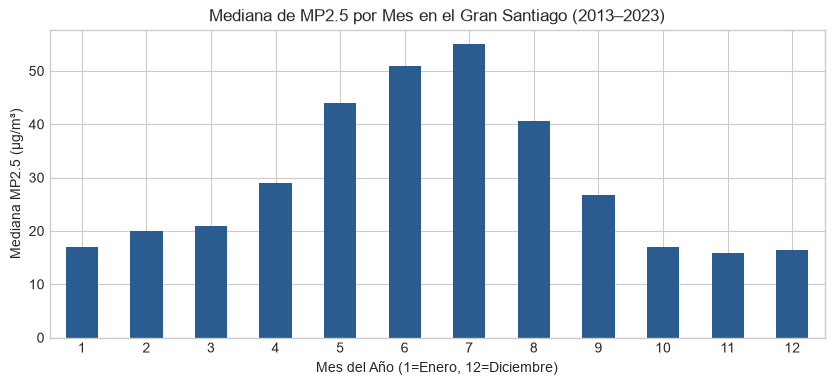

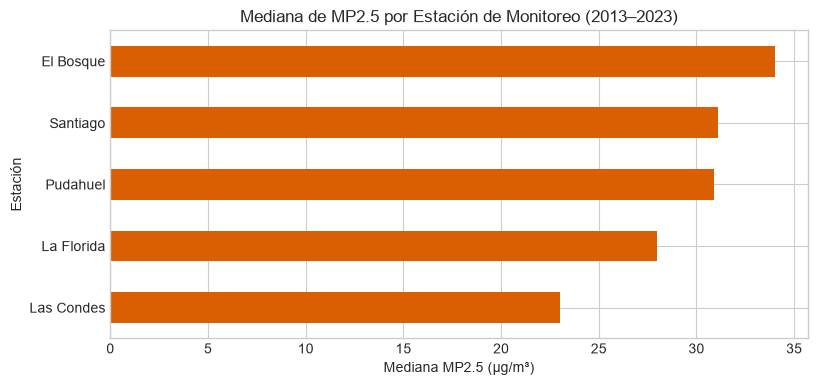

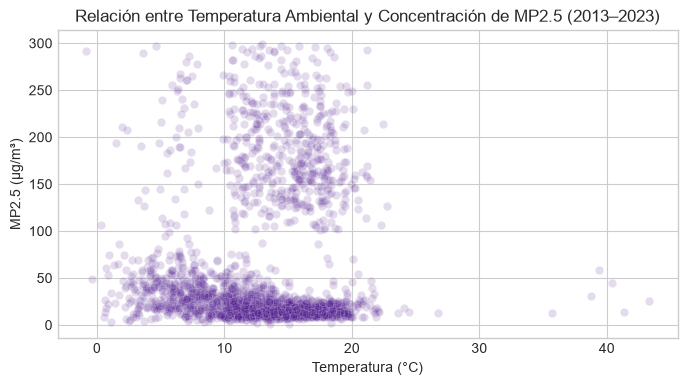

In [4]:
# Gráfico 1: Estacionalidad mensual de MP2.5 (Demostración de T)
plt.figure(figsize=(10, 4))
df_estudio.groupby('Month')['MP2_5'].median().plot(kind='bar', color='#2b5c8f')
plt.title('Mediana de MP2.5 por Mes en el Gran Santiago (2013–2023)')
plt.xlabel('Mes del Año (1=Enero, 12=Diciembre)')
plt.ylabel('Mediana MP2.5 (µg/m³)')
plt.xticks(rotation=0)
plt.savefig('../figures/estacionalidad_mensual.png', bbox_inches='tight')
plt.show()

# Gráfico 2: Comparación por Estación de monitoreo (Demostración de X)
plt.figure(figsize=(9, 4))
df_estudio.groupby('Estacion')['MP2_5'].median().sort_values().plot(kind='barh', color='#d95f02')
plt.title('Mediana de MP2.5 por Estación de Monitoreo (2013–2023)')
plt.xlabel('Mediana MP2.5 (µg/m³)')
plt.ylabel('Estación')
plt.savefig('../figures/comparacion_estaciones.png', bbox_inches='tight')
plt.show()

# Gráfico 3 opcional: Relación Temperatura vs MP2.5 (Efecto Inversión Térmica)
plt.figure(figsize=(8, 4))
sns.scatterplot(
    data=df_estudio[(df_estudio['MP2_5'] < 300) & (df_estudio['Temperatura'] < 45)], 
    x='Temperatura', y='MP2_5', alpha=0.15, color='#4a148c'
)
plt.title('Relación entre Temperatura Ambiental y Concentración de MP2.5 (2013–2023)')
plt.xlabel('Temperatura (°C)')
plt.ylabel('MP2.5 (µg/m³)')
plt.savefig('../figures/dispersion_temperatura_mp25.png', bbox_inches='tight')
plt.show()